## Import Required Libaries

In [85]:
import queue
import time
import datetime
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 1. Event

In [88]:
class Event:
    """
    Base class for all event objects.
    """
    pass

class MarketEvent(Event):
    """
    Handles the event of receiving a new market update (a new bar).
    """
    def __init__(self):
        self.type = 'MARKET'

class SignalEvent(Event):
    """
    Handles the event of sending a Signal from a Strategy object.
    This is received by a Portfolio object and acted upon.
    """
    def __init__(self, symbol, datetime, signal_type):
        self.type = 'SIGNAL'
        self.symbol = symbol
        self.datetime = datetime
        self.signal_type = signal_type # 'LONG' or 'SHORT' or 'EXIT'

class OrderEvent(Event):
    """
    Handles the event of sending an Order to an execution system.
    The order contains a symbol, a type (market or limit),
    quantity and a direction.
    """
    def __init__(self, symbol, order_type, quantity, direction):
        self.type = 'ORDER'
        self.symbol = symbol
        self.order_type = order_type # 'MKT'
        self.quantity = quantity
        self.direction = direction # 'BUY' or 'SELL'

    def print_order(self):
        print(
            f"Order: Symbol={self.symbol}, Type={self.order_type}, "
            f"Quantity={self.quantity}, Direction={self.direction}"
        )

class FillEvent(Event):
    """
    Encapsulates the notion of a filled order, as returned from a brokerage.
    Stores the quantity of an instrument actually filled and at what price.
    Furthermore, it stores the commission of the trade from the brokerage.
    """
    def __init__(self, timeindex, symbol, exchange, quantity, direction, fill_cost, commission=0.0):
        self.type = 'FILL'
        self.timeindex = timeindex
        self.symbol = symbol
        self.exchange = 'SimulatedExchange'
        self.quantity = quantity
        self.direction = direction
        self.fill_cost = fill_cost
        self.commission = commission

## Event Queue

## Data Handler

In [93]:
from abc import ABCMeta, abstractmethod

class DataHandler(metaclass=ABCMeta):
    @abstractmethod
    def get_latest_bar(self, symbol):
        raise NotImplementedError("Should implement get_latest_bar()")

    @abstractmethod
    def update_bars(self):
        raise NotImplementedError("Should implement update_bars()")

class HistoricCSVDataHandler(DataHandler):
    """
    HistoricCSVDataHandler is designed to read CSV files for
    each requested symbol from disk and provide an interface
    to obtain the "latest" bar in a manner useful for vectorized
    and event-driven backtesting.
    """
    def __init__(self, events, csv_dir, symbol_list):
        self.events = events
        self.csv_dir = csv_dir
        self.symbol_list = symbol_list

        self.symbol_data = {}
        self.latest_symbol_data = {}
        self.continue_backtest = True
        self.bar_index = 0

        self._open_convert_csv_files()

    def _open_convert_csv_files(self):
        """
        Opens the CSV files from the data directory, converting
        them into pandas DataFrames.
        """
        comb_index = None
        for s in self.symbol_list:
            # Load the CSV file with no header, instead passing in column names
            # For this example, we'll simulate the CSV file using an in-memory string
            csv_content = """2020-01-02,100,102,99,101
2020-01-03,101,103,100,102
2020-01-06,102,105,101,104
2020-01-07,104,106,103,105
2020-01-08,105,105,102,103
2020-01-09,103,107,103,106
2020-01-10,106,108,105,107
2020-01-13,107,110,106,109
2020-01-14,109,110,108,109
2020-01-15,109,112,108,111""" # Sample data

            self.symbol_data[s] = pd.read_csv(
                io.StringIO(csv_content), header=None, index_col=0,
                names=['Date', 'Open', 'High', 'Low', 'Close']
            )
            self.symbol_data[s].index = pd.to_datetime(self.symbol_data[s].index)


        # For simplicity, we'll use one symbol's index as the master index
        self.master_index = self.symbol_data[self.symbol_list[0]].index


    def _get_new_bar(self, symbol):
        """
        Returns the latest bar from the data feed.
        """
        for bar in self.symbol_data[symbol].iloc[self.bar_index:self.bar_index+1].itertuples():
            yield bar

    def get_latest_bar(self, symbol):
        """
        Returns the last updated bar.
        """
        try:
            bars_list = self.latest_symbol_data[symbol]
        except KeyError:
            print("That symbol is not available in the historical data set.")
            raise
        else:
            return bars_list[-1]

    def update_bars(self):
        """
        Pushes the latest bar to the latest_symbol_data structure
        for all symbols in the symbol list.
        """
        if self.bar_index < len(self.master_index):
            for s in self.symbol_list:
                try:
                    bar = next(self._get_new_bar(s))
                except StopIteration:
                    self.continue_backtest = False
                else:
                    if bar is not None:
                        if s not in self.latest_symbol_data:
                            self.latest_symbol_data[s] = []
                        self.latest_symbol_data[s].append(bar)
            self.bar_index += 1
            self.events.put(MarketEvent())
        else:
            self.continue_backtest = False

## Strategy

In [96]:
class Strategy(metaclass=ABCMeta):
    @abstractmethod
    def calculate_signals(self, event):
        raise NotImplementedError("Should implement calculate_signals()")

class MovingAverageCrossStrategy(Strategy):
    """
    A simple moving average crossover strategy.
    """
    def __init__(self, bars, events, short_window=5, long_window=10):
        self.bars = bars
        self.symbol_list = self.bars.symbol_list
        self.events = events
        self.short_window = short_window
        self.long_window = long_window

        self.bought = self._calculate_initial_bought()

    def _calculate_initial_bought(self):
        """
        Adds keys to the bought dictionary for all symbols and sets them to 'OUT'.
        """
        bought = {}
        for s in self.symbol_list:
            bought[s] = 'OUT'
        return bought

    def calculate_signals(self, event):
        """
        Generates a new set of signals based on the MAC
        SMA with the short window crossing the long window.
        """
        if event.type == 'MARKET':
            for s in self.symbol_list:
                bars = self.bars.latest_symbol_data[s]
                if len(bars) >= self.long_window:
                    # Create pandas Series for calculation
                    close_prices = pd.Series([b.Close for b in bars])
                    short_sma = close_prices.rolling(window=self.short_window).mean()
                    long_sma = close_prices.rolling(window=self.long_window).mean()

                    # Trading signal logic
                    if short_sma.iloc[-1] > long_sma.iloc[-1] and self.bought[s] == 'OUT':
                        dt = self.bars.get_latest_bar(s).Index
                        signal = SignalEvent(s, dt, 'LONG')
                        self.events.put(signal)
                        self.bought[s] = 'LONG'

                    elif short_sma.iloc[-1] < long_sma.iloc[-1] and self.bought[s] == 'LONG':
                        dt = self.bars.get_latest_bar(s).Index
                        signal = SignalEvent(s, dt, 'EXIT')
                        self.events.put(signal)
                        self.bought[s] = 'OUT'

## Portfolio

In [99]:
class Portfolio:
    """
    The Portfolio class handles the positions and market value of all
    instruments at a resolution of a "bar".
    """
    def __init__(self, bars, events, start_date, initial_capital=100000.0):
        self.bars = bars
        self.events = events
        self.symbol_list = self.bars.symbol_list
        self.start_date = start_date
        self.initial_capital = initial_capital

        self.all_positions = self.construct_all_positions()
        self.current_holdings = self.construct_current_holdings()
        # --- FIX: Add a list to store historical holdings for performance tracking
        self.all_holdings = [self.current_holdings.copy()]


    def construct_all_positions(self):
        """
        Constructs the positions list using the start_date
        to determine when the time index will begin.
        """
        d = dict( (k,v) for k, v in [(s, 0) for s in self.symbol_list] )
        d['datetime'] = self.start_date
        return [d]

    def construct_current_holdings(self):
        """
        Constructs the dictionary that will hold the instantaneous
        value of the portfolio across all symbols.
        """
        d = dict( (k,v) for k, v in [(s, 0.0) for s in self.symbol_list] )
        d['datetime'] = self.start_date
        d['cash'] = self.initial_capital
        d['commission'] = 0.0
        d['total'] = self.initial_capital
        return d

    def update_timeindex(self, event):
        """
        Adds a new record to the positions matrix for the current
        market data bar. This reflects the PREVIOUS bar, i.e. all
        current market data at this stage is known (OLHCVI).
        Makes use of a MarketEvent from the events queue.
        """
        latest_datetime = self.bars.get_latest_bar(self.symbol_list[0]).Index

        # Update positions
        dp = self.all_positions[-1].copy()
        dp['datetime'] = latest_datetime
        self.all_positions.append(dp)


        # Update holdings
        dh = self.current_holdings.copy()
        dh['datetime'] = latest_datetime
        dh['total'] = dh['cash'] # Reset total to cash before re-calculating

        for s in self.symbol_list:
            # Approximation of the real value
            market_value = self.all_positions[-1][s] * self.bars.get_latest_bar(s).Close
            dh[s] = market_value
            dh['total'] += market_value
        
        # --- FIX: Append the new holdings state to the historical list
        self.all_holdings.append(dh)
        self.current_holdings = dh


    def update_positions_from_fill(self, fill):
        """
        Takes a FillEvent and updates the position matrix to
        reflect the new position.
        """
        fill_dir = 0
        if fill.direction == 'BUY':
            fill_dir = 1
        if fill.direction == 'SELL':
            fill_dir = -1

        self.all_positions[-1][fill.symbol] += fill_dir * fill.quantity

    def update_holdings_from_fill(self, fill):
        """
        Takes a FillEvent and updates the holdings matrix to
        reflect the holdings value.
        """
        fill_dir = 0
        if fill.direction == 'BUY':
            fill_dir = 1
        if fill.direction == 'SELL':
            fill_dir = -1

        fill_cost = self.bars.get_latest_bar(fill.symbol).Close
        cost = fill_dir * fill_cost * fill.quantity
        
        # Update the holdings for the last recorded timestep
        self.all_holdings[-1][fill.symbol] += cost
        self.all_holdings[-1]['commission'] += fill.commission
        self.all_holdings[-1]['cash'] -= (cost + fill.commission)
        self.all_holdings[-1]['total'] -= (cost + fill.commission)


    def generate_naive_order(self, signal):
        """
        Simply files an Order object as a market order for a fixed quantity.
        """
        order = None
        symbol = signal.symbol
        direction = signal.signal_type
        
        # Simple position sizing: 100 shares
        mkt_quantity = 100

        cur_quantity = self.all_positions[-1][symbol]
        order_type = 'MKT'

        if direction == 'LONG' and cur_quantity == 0:
            order = OrderEvent(symbol, order_type, mkt_quantity, 'BUY')
        if direction == 'SHORT' and cur_quantity == 0:
            order = OrderEvent(symbol, order_type, mkt_quantity, 'SELL')
        if direction == 'EXIT' and cur_quantity > 0:
            order = OrderEvent(symbol, order_type, abs(cur_quantity), 'SELL')
        if direction == 'EXIT' and cur_quantity < 0:
            order = OrderEvent(symbol, order_type, abs(cur_quantity), 'BUY')

        return order

    def update_signal(self, event):
        if event.type == 'SIGNAL':
            order_event = self.generate_naive_order(event)
            if order_event:
                self.events.put(order_event)

## Execution Handler

In [113]:
class ExecutionHandler(metaclass=ABCMeta):
    @abstractmethod
    def execute_order(self, event):
        raise NotImplementedError("Should implement execute_order()")

class SimulatedExecutionHandler(ExecutionHandler):
    """
    The simulated execution handler simply converts all order
    objects into their equivalent fill objects without latency,
    slippage or fill-ratio issues.
    """
    def __init__(self, events, bars):
        self.events = events
        self.bars = bars

    def execute_order(self, event):
        """
        Simply converts Order objects into Fill objects naively.
        This means no slippage or fill ratio modelling.
        """
        if event.type == 'ORDER':
            # For simplicity, we use the current bar's close price
            # A more realistic model would use the open price of the *next* bar
            fill_event = FillEvent(
                datetime.datetime.now(datetime.UTC), event.symbol,
                'ARCA', event.quantity, event.direction,
                self.bars.get_latest_bar(event.symbol).Close, commission=5.0
            )
            self.events.put(fill_event)

## Performance Tracker

In [115]:
class PerformanceTracker:
    def __init__(self, portfolio):
        self.portfolio = portfolio
        self.equity_curve = None

    def _create_equity_curve_dataframe(self):
        """
        Creates a pandas DataFrame from the portfolio's holdings history.
        """
        # --- FIX: Use the historical list of holdings, not the single current one
        curve = pd.DataFrame(self.portfolio.all_holdings)
        curve.set_index('datetime', inplace=True)
        curve['returns'] = curve['total'].pct_change()
        curve['equity_curve'] = (1.0 + curve['returns']).cumprod()
        self.equity_curve = curve

    def output_summary_stats(self):
        """
        Creates a list of summary statistics for the portfolio.
        """
        self._create_equity_curve_dataframe()
        total_return = self.equity_curve['equity_curve'].iloc[-1]
        returns = self.equity_curve['returns']
        pnl = self.equity_curve['equity_curve']

        # Sharpe Ratio
        sharpe_ratio = self.create_sharpe_ratio(returns)
        # Max Drawdown
        drawdown, max_dd = self.create_drawdowns(pnl)
        self.equity_curve['drawdown'] = drawdown

        stats = [
            ("Total Return", f"{(total_return - 1.0) * 100.0:.2f}%"),
            ("Sharpe Ratio", f"{sharpe_ratio:.2f}"),
            ("Max Drawdown", f"{max_dd * 100.0:.2f}%")
        ]
        return stats

    def create_sharpe_ratio(self, returns, periods=252):
        """
        Create the Sharpe ratio for the strategy, based on a
        benchmark of zero (i.e. no risk-free rate).
        """
        if np.std(returns) == 0:
            return 0.0
        return np.sqrt(periods) * (np.mean(returns)) / np.std(returns)

    def create_drawdowns(self, pnl):
        """
        Calculate the largest peak-to-trough drawdown of the PnL curve
        as well as the duration of the drawdown.
        """
        hwm = [0]
        drawdown = pd.Series(index=pnl.index)
        duration = pd.Series(index=pnl.index)

        for t in range(1, len(pnl)):
            hwm.append(max(hwm[t-1], pnl[t]))
            drawdown[t] = (hwm[t] - pnl[t]) / hwm[t] if hwm[t] != 0 else 0
            duration[t] = 0 if drawdown[t] == 0 else duration[t-1] + 1
        return drawdown, drawdown.max()

    def plot_performance(self):
        """
        Plots the equity curve and drawdown.
        """
        if self.equity_curve is None:
            self._create_equity_curve_dataframe()

        fig = plt.figure(figsize=(12, 8))
        fig.patch.set_facecolor('white')

        # Plot equity curve
        ax1 = fig.add_subplot(211, ylabel='Portfolio value in $')
        self.equity_curve['total'].plot(ax=ax1, lw=2.)
        ax1.grid(True)
        ax1.set_title('Equity Curve')

        # Plot drawdown
        ax2 = fig.add_subplot(212, ylabel='Drawdown in %')
        (self.equity_curve['drawdown'] * 100).plot(ax=ax2, color='red', lw=2.)
        ax2.grid(True)
        ax2.set_title('Maximum Drawdown')

        plt.tight_layout()
        plt.show()

## Backtest Driver

In [117]:
def run_backtest(symbol_list, initial_capital, start_date, csv_dir, strategy_class, strategy_params):
    events = queue.Queue()

    # Declare the components
    bars = HistoricCSVDataHandler(events, csv_dir, symbol_list)
    strategy = strategy_class(bars, events, **strategy_params)
    port = Portfolio(bars, events, start_date, initial_capital)
    broker = SimulatedExecutionHandler(events, bars) # Pass bars to broker

    while True:
        # Update the bars (specific backtest code, as opposed to live trading)
        if bars.continue_backtest == True:
            bars.update_bars()
        else:
            break

        # Handle the events
        while True:
            try:
                event = events.get(False)
            except queue.Empty:
                break
            else:
                if event is not None:
                    if event.type == 'MARKET':
                        strategy.calculate_signals(event)
                        port.update_timeindex(event)

                    elif event.type == 'SIGNAL':
                        port.update_signal(event)

                    elif event.type == 'ORDER':
                        broker.execute_order(event)

                    elif event.type == 'FILL':
                        port.update_positions_from_fill(event)
                        port.update_holdings_from_fill(event)

        time.sleep(0.001) # sleep for 1 millisecond

    return port

## Running the Backtest and Visualising Results

Running Backtest...
Backtest Finished.

--- Performance Stats ---
Total Return: -11.10%
Sharpe Ratio: -5.29
Max Drawdown: 11.10%


/var/folders/r4/lt0cvy3d3b5ff5lbn8k4bb480000gn/T/ipykernel_29112/2433301526.py:58: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hwm.append(max(hwm[t-1], pnl[t]))
/var/folders/r4/lt0cvy3d3b5ff5lbn8k4bb480000gn/T/ipykernel_29112/2433301526.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  drawdown[t] = (hwm[t] - pnl[t]) / hwm[t] if hwm[t] != 0 else 0
/var/folders/r4/lt0cvy3d3b5ff5lbn8k4bb480000gn/T/ipykernel_29112/2433301526.py:59: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To se

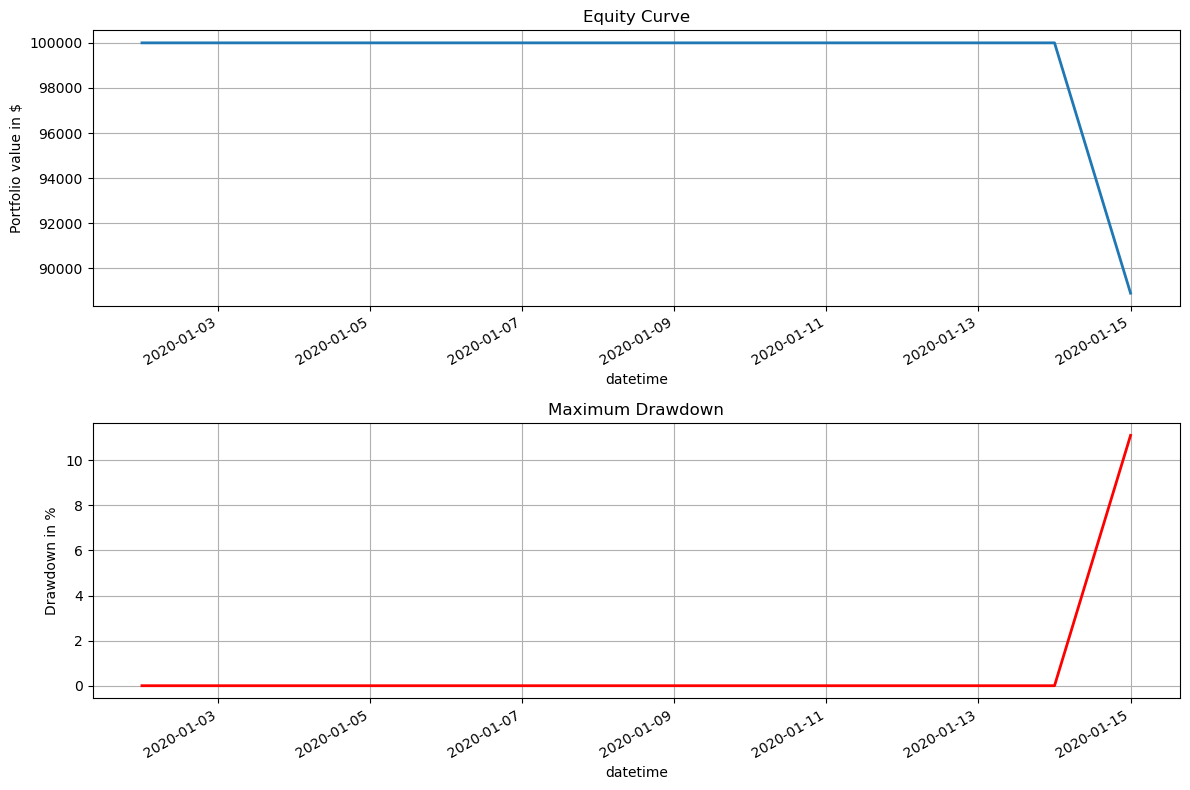

In [119]:
if __name__ == "__main__":
    # --- Configuration ---
    symbol_list = ['AAPL']  # Just one symbol for this example
    initial_capital = 100000.0
    start_date = datetime.datetime(2020, 1, 2)
    csv_dir = './data/' # Not used in this example as data is in-memory

    # --- Strategy Parameters ---
    strategy_params = {'short_window': 5, 'long_window': 10}

    # --- Run ---
    print("Running Backtest...")
    portfolio = run_backtest(
        symbol_list,
        initial_capital,
        start_date,
        csv_dir,
        MovingAverageCrossStrategy,
        strategy_params
    )
    print("Backtest Finished.")

    # --- Performance ---
    tracker = PerformanceTracker(portfolio)
    print("\n--- Performance Stats ---")
    stats = tracker.output_summary_stats()
    for stat in stats:
        print(f"{stat[0]}: {stat[1]}")

    tracker.plot_performance()
